In [2]:
#inputs
import numpy as np
import pathlib as Path

# Input array of shape coordinates (triangle)
shape_points = np.array([
    [0.7, 0.3],
    [0.7, 0.7],
    [0.3, 0.7]
])

num_particles = 100
bounce_back_multiplier = 1.1
max_bounces = 5
u = 0.2
v = 0.1
dt = 0.1

In [10]:
#run

from matplotlib.animation import FuncAnimation
ani = FuncAnimation(fig, animate, frames=200, interval=50, blit=True)
ani.save('particle_flo_tseter.mp4', writer='ffmpeg', fps=20)
plt.show()

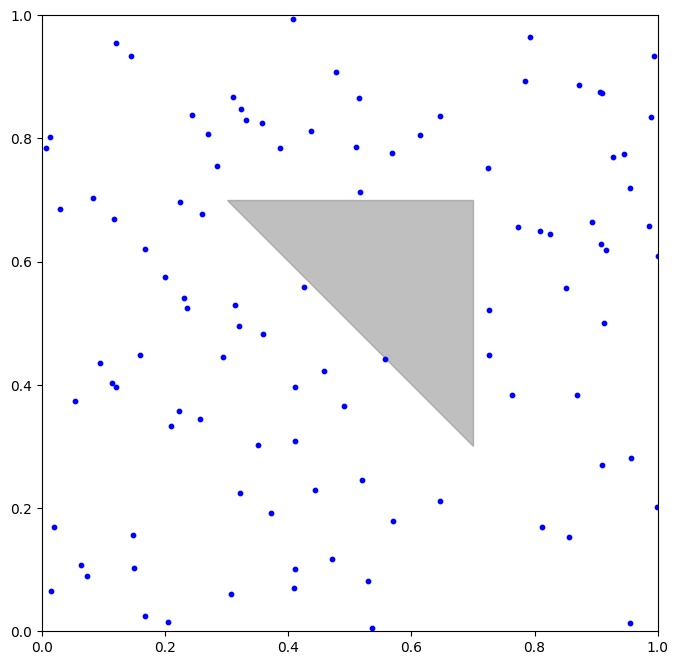

In [9]:
# simulate

# Grid setup
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

grid_size = 100
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
X, Y = np.meshgrid(x, y)
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')

# Use the original shape points for visualization
shape_patch = Polygon(shape_points, closed=True, color='gray', alpha=0.5)
ax.add_patch(shape_patch)

scatter = ax.scatter(particles[:, 0], particles[:, 1], s=10, color='blue')

def animate(frame):
    global particles, bounce_counts
    particles, bounce_counts = update_particles(
        particles, bounce_counts, dt, bounce_back_multiplier, max_bounces
    )
    scatter.set_offsets(particles)
    return scatter,

In [6]:
# PIC

from matplotlib.path import Path
shape_center = np.mean(shape_points, axis=0)
def flow_field(x, y):

    return np.array([u, v])

def point_in_polygon(point, polygon):
    path = Path(polygon)
    return path.contains_point(point)

def find_polygon_normal(point, polygon):
    min_dist = float('inf')
    closest_normal = np.array([0, 0])


    center = np.mean(polygon, axis=0)

    for i in range(len(polygon)):
        p1 = polygon[i]
        p2 = polygon[(i + 1) % len(polygon)]
        edge = p2 - p1

        normal = np.array([-edge[1], edge[0]])
        normal /= np.linalg.norm(normal)

        t = np.dot(point - p1, edge) / np.dot(edge, edge)
        t = np.clip(t, 0, 1)
        projection = p1 + t * edge
        dist = np.linalg.norm(point - projection)

        if dist < min_dist:
            min_dist = dist
            closest_normal = normal
    # Use the center parameter (fixed this line)
    if np.dot(point - center, closest_normal) < 0:
        closest_normal *= -1

    return closest_normal

particles = []
bounce_counts = []

while len(particles) < num_particles:
    x_rand, y_rand = np.random.rand(), np.random.rand()
    if not point_in_polygon((x_rand, y_rand), shape_points):
        particles.append([x_rand, y_rand])
        bounce_counts.append(0)

particles = np.array(particles)
bounce_counts = np.array(bounce_counts)

def update_particles(particles, bounce_counts, dt, bounce_back_multiplier, max_bounces):
    new_particles = []
    new_bounce_counts = []

    for i in range(len(particles)):
        pos = particles[i]
        velocity = flow_field(pos[0], pos[1])
        new_pos = pos + velocity * dt
        count = bounce_counts[i]

        if point_in_polygon(new_pos, shape_points):
            normal = find_polygon_normal(new_pos, shape_points)
            velocity = velocity - 2 * np.dot(velocity, normal) * normal
            new_pos = pos + velocity * dt * bounce_back_multiplier
            count += 1  # Count a bounce

        if count <= max_bounces:
            new_particles.append(new_pos)
            new_bounce_counts.append(count)

    return np.array(new_particles), np.array(new_bounce_counts)